In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r'C:\Users\shriv\Documents\churn_prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic info
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())

Rows: 7043
Columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [2]:
# Check missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Fix TotalCharges column (it loads as text, needs to be a number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

print(f"\nAfter cleaning — Rows: {df.shape[0]}")
print(f"TotalCharges type: {df['TotalCharges'].dtype}")

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

After cleaning — Rows: 7032
TotalCharges type: float64


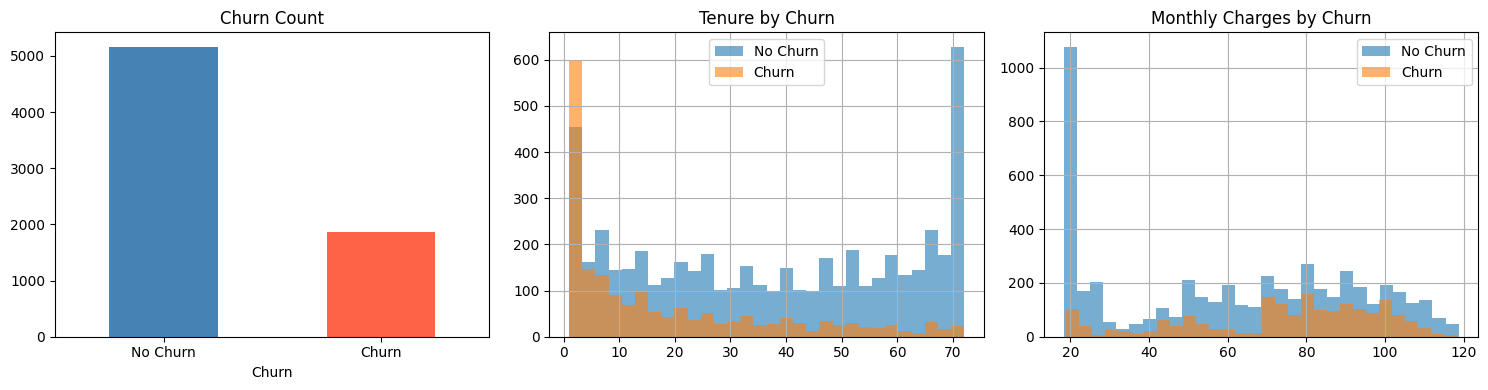

In [3]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 - Churn count
df['Churn'].value_counts().plot(kind='bar', ax=axes[0],
                                color=['steelblue', 'tomato'])
axes[0].set_title('Churn Count')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Plot 2 - Tenure vs Churn
df.groupby('Churn')['tenure'].hist(alpha=0.6, ax=axes[1], bins=30)
axes[1].set_title('Tenure by Churn')
axes[1].legend(['No Churn', 'Churn'])

# Plot 3 - Monthly Charges vs Churn
df.groupby('Churn')['MonthlyCharges'].hist(alpha=0.6, ax=axes[2], bins=30)
axes[2].set_title('Monthly Charges by Churn')
axes[2].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [4]:
# Convert Yes/No columns to 1/0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['gender'] = (df['gender'] == 'Male').astype(int)
df['Partner'] = (df['Partner'] == 'Yes').astype(int)
df['Dependents'] = (df['Dependents'] == 'Yes').astype(int)
df['PhoneService'] = (df['PhoneService'] == 'Yes').astype(int)
df['PaperlessBilling'] = (df['PaperlessBilling'] == 'Yes').astype(int)

# Convert remaining text columns using get_dummies
df = pd.get_dummies(df, columns=[
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
], drop_first=True)

# Drop customer ID as it's not useful
df.drop(columns=['customerID'], inplace=True)

print(f"Total columns after encoding: {df.shape[1]}")
print(f"\nFirst 3 rows:")
df.head(3)

Total columns after encoding: 31

First 3 rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nChurn rate in data: {y.mean():.1%}")

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTraining rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")

# Fix class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE training rows: {X_train_res.shape[0]}")
print(f"Churn balance after SMOTE: {y_train_res.value_counts().to_dict()}")

Features shape: (7032, 30)
Target shape: (7032,)

Churn rate in data: 26.6%

Training rows: 5625
Testing rows:  1407

After SMOTE training rows: 8260
Churn balance after SMOTE: {0: 4130, 1: 4130}


In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train the model
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_res, y_train_res)
print("Model trained successfully!")

# Test the model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Score
auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC Score: {auc:.4f}")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))

Model trained successfully!

AUC-ROC Score: 0.8198

Detailed Report:
              precision    recall  f1-score   support

        Stay       0.86      0.81      0.83      1033
       Churn       0.54      0.63      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.76      0.77      1407



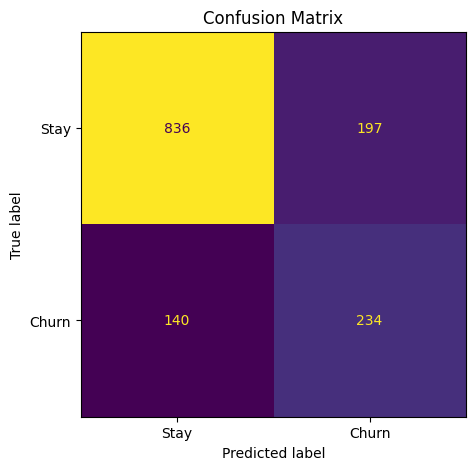

Correctly predicted STAY:  836
Correctly predicted CHURN: 234
Wrongly predicted as CHURN (false alarm): 197
Missed churners (predicted stay but left): 140


In [7]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Stay', 'Churn'],
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion Matrix')
plt.show()

# Plain english explanation
tn, fp, fn, tp = 0, 0, 0, 0
for true, pred in zip(y_test, y_pred):
    if true == 0 and pred == 0: tn += 1
    elif true == 0 and pred == 1: fp += 1
    elif true == 1 and pred == 0: fn += 1
    else: tp += 1

print(f"Correctly predicted STAY:  {tn}")
print(f"Correctly predicted CHURN: {tp}")
print(f"Wrongly predicted as CHURN (false alarm): {fp}")
print(f"Missed churners (predicted stay but left): {fn}")

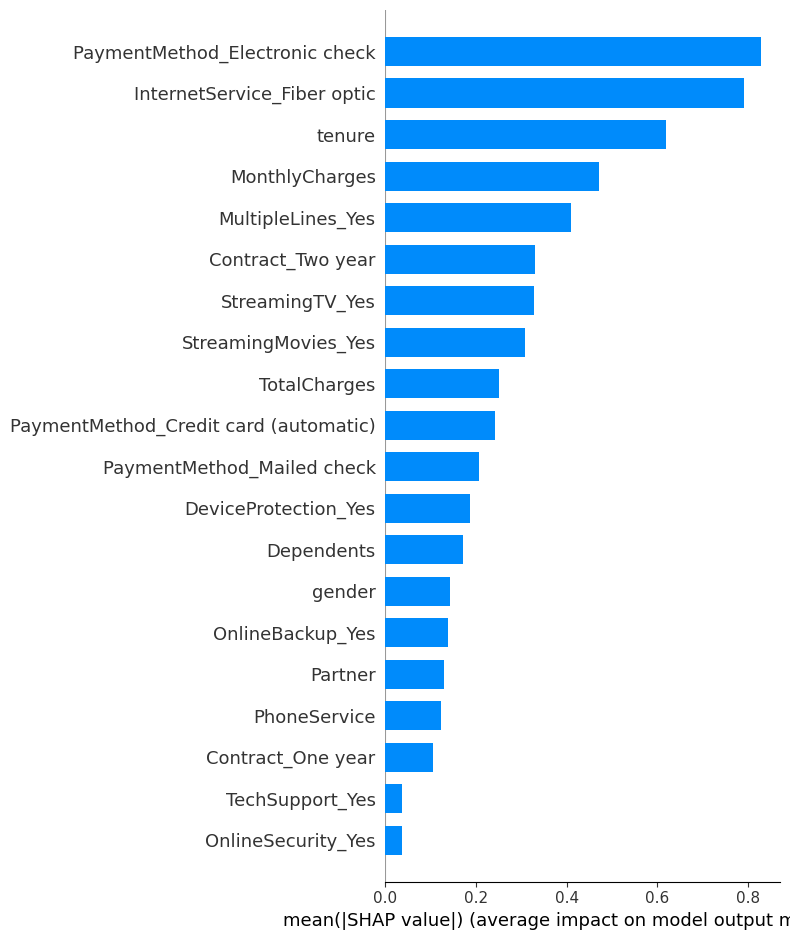

In [8]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1 - Which features matter most (bar chart)
shap.summary_plot(shap_values, X_test, plot_type='bar', 
                  show=True)

In [9]:
import pickle
import os

# Create models folder if not exists
os.makedirs('../models', exist_ok=True)

# Save the model
with open('../models/xgb_churn.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the feature names
feature_names = X_test.columns.tolist()
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Model saved successfully!")
print(f"Features saved: {len(feature_names)}")
print("\nFeature names:")
for feat in feature_names:
    print(f"  - {feat}")

Model saved successfully!
Features saved: 30

Feature names:
  - gender
  - SeniorCitizen
  - Partner
  - Dependents
  - tenure
  - PhoneService
  - PaperlessBilling
  - MonthlyCharges
  - TotalCharges
  - MultipleLines_No phone service
  - MultipleLines_Yes
  - InternetService_Fiber optic
  - InternetService_No
  - OnlineSecurity_No internet service
  - OnlineSecurity_Yes
  - OnlineBackup_No internet service
  - OnlineBackup_Yes
  - DeviceProtection_No internet service
  - DeviceProtection_Yes
  - TechSupport_No internet service
  - TechSupport_Yes
  - StreamingTV_No internet service
  - StreamingTV_Yes
  - StreamingMovies_No internet service
  - StreamingMovies_Yes
  - Contract_One year
  - Contract_Two year
  - PaymentMethod_Credit card (automatic)
  - PaymentMethod_Electronic check
  - PaymentMethod_Mailed check
